# ANCHOR Walkthrough

This notebook walks through ANCHOR tile-level feature extraction step by step:

1. Load the encoder and preprocessing transform
2. Load a test image (`assets/assets/test_image.png`)
3. Apply transformations (resize, normalization)
4. Run the encoder forward pass
5. Convert token output to the 2560-d embedding


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision import transforms

NOTEBOOK_DIR = os.path.abspath(".")
ROOT_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
WEIGHTS_DIR = os.path.join(ROOT_DIR, "weights")
sys.path.insert(0, ROOT_DIR) 

from anchor.get_encoder import get_encoder, to_anchor_embedding

IMAGE_PATH = os.path.join(ROOT_DIR, "assets", "test_image.png")
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

print(f"image path : {IMAGE_PATH}")
print(f"device     : {DEVICE}")


/home/yw/miniconda3/envs/anchor/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device     : cuda:2


## Step 1 — Load encoder

`get_encoder()` reads `config.json` + `pytorch_model.bin` and returns:
- `model`: ViT-Huge backbone (`vit_huge_patch14_224`)
- `transform`: timm preprocessing built from `pretrained_cfg`

In [2]:
model, transform = get_encoder(device=DEVICE, assets_dir=WEIGHTS_DIR)

n_params = sum(p.numel() for p in model.parameters())
print(f"architecture : vit_huge_patch14_224")
print(f"parameters   : {n_params / 1e6:.1f} M")
print(f"transform    : {transform}")


architecture : vit_huge_patch14_224
parameters   : 631.2 M
transform    : Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


## Step 2 — Load image

Load image as RGB. The model expects 224×224 tiles.

original size : (224, 224)  (W x H)
mode          : RGB


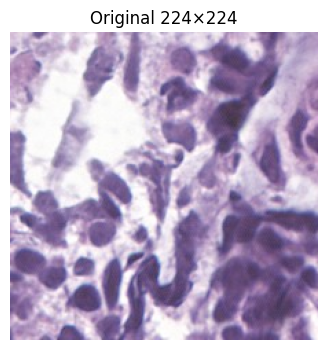

In [3]:
image = Image.open(IMAGE_PATH).convert("RGB")
print(f"original size : {image.size}  (W x H)")
print(f"mode          : {image.mode}")

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title(f"Original {image.size[0]}×{image.size[1]}")
plt.axis("off")
plt.show()

## Step 3 — Apply transform

The full preprocessing pipeline converts the PIL image to a normalized float tensor `[3, 224, 224]`.

After ImageNet normalization, each channel is `(pixel - mean) / std`, so values are **no longer displayable RGB** (often around -2 to +3). Below we show:
- the 3 normalized channels separately (R / G / B)
- the **denormalized** preview, which should look like the resized image


In [4]:
tensor = transform(image)
batch = tensor.unsqueeze(0).to(DEVICE)  # add batch dim -> [1, 3, 224, 224]

print(f"tensor shape : {tuple(tensor.shape)}")
print(f"batch shape  : {tuple(batch.shape)}")
print(f"dtype        : {tensor.dtype}")
print(f"value range  : [{tensor.min().item():.4f}, {tensor.max().item():.4f}]")
print(f"mean / std   : {tensor.mean().item():.4f} / {tensor.std().item():.4f}")

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


tensor shape : (3, 224, 224)
batch shape  : (1, 3, 224, 224)
dtype        : torch.float32
value range  : [-1.1779, 2.6400]
mean / std   : 0.9817 / 0.9697


## Step 4 — Encoder forward pass

The model outputs a token sequence:

| Index | Token |
|-------|-------|
| 0 | class token |
| 1–4 | register tokens (skipped for embedding) |
| 5–260 | patch tokens (16×16 = 256 patches) |

Output shape: `[B, 261, 1280]`

In [5]:
model.eval()
with torch.no_grad():
    tokens = model(batch)

print(f"token output shape : {tuple(tokens.shape)}")
print(f"token mean / std   : {tokens.mean().item():.6f} / {tokens.std().item():.6f}")
print()
print(f"class token [0]    : shape={tuple(tokens[:, 0].shape)}, mean={tokens[:, 0].mean().item():.6f}")
print(f"register [1:5]     : shape={tuple(tokens[:, 1:5].shape)}, mean={tokens[:, 1:5].mean().item():.6f}")
print(f"patch tokens [5:]  : shape={tuple(tokens[:, 5:].shape)}, mean={tokens[:, 5:].mean().item():.6f}")

token output shape : (1, 261, 1280)
token mean / std   : -0.009795 / 0.488278

class token [0]    : shape=(1, 1280), mean=-0.023360
register [1:5]     : shape=(1, 4, 1280), mean=-0.000111
patch tokens [5:]  : shape=(1, 256, 1280), mean=-0.009893


## Step 5 — Build 2560-d embedding

Production embedding = `class_token` concatenated with `mean(patch_tokens)`:

```python
embedding = torch.cat([tokens[:, 0], tokens[:, 5:].mean(1)], dim=-1)  # [B, 2560]
```

In [6]:
embedding = to_anchor_embedding(tokens)

print(f"embedding shape    : {tuple(embedding.shape)}")

embedding shape    : (1, 2560)
